In [2]:
# import everything
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightkurve as lk
import os

# astronomy packages
from astropy.io import fits
from astropy.table import Table

/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
def phase_fold(lc, period, t0):
    """
    Phase fold a light curve.

    Parameters:
    lc : LightCurve : astropy table
        The light curve to phase fold.
    period : float
        The period of the signal in days.
    t0 : float
        The reference time (e.g., time of transit) in days.

    Returns:
    phased_lc : LightCurve
        The phase-folded light curve.
    """
    # Calculate the phase between 0 and 1
    phase = ((lc.time.value - t0) / period) % 1

    lc['phase'] = phase

    return lc

In [4]:
# read the local exoplanet archive data
exo_archive = pd.read_csv('../data/TOI_2026.06.28_09.42.00.csv', skiprows=90)

exo_archive_CP = exo_archive[exo_archive['tfopwg_disp'] == 'CP']

tic_ids = exo_archive_CP['tid'].sample(n=1, random_state=1, replace=False).tolist()

tic_id_adopted = 381979901
print(f"Selected TIC ID: {tic_id_adopted}")

Selected TIC ID: 381979901


In [5]:
# data download module
search = lk.search_lightcurve(f"TIC {tic_id_adopted}", author='SPOC', exptime=120)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 12,2019,SPOC,120,381979901,0.0
1,TESS Sector 13,2019,SPOC,120,381979901,0.0
2,TESS Sector 27,2020,SPOC,120,381979901,0.0
3,TESS Sector 28,2020,SPOC,120,381979901,0.0
4,TESS Sector 29,2020,SPOC,120,381979901,0.0
5,TESS Sector 30,2020,SPOC,120,381979901,0.0
6,TESS Sector 31,2020,SPOC,120,381979901,0.0
7,TESS Sector 32,2020,SPOC,120,381979901,0.0
8,TESS Sector 33,2020,SPOC,120,381979901,0.0


In [6]:

lc_collection = search.download_all(quality_bitmask='hardest', download_dir='../data/fits/')


In [7]:
lc_collection_1 = lc_collection.stitch().remove_nans()
lc_collection_1

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1631.1961468450756,9.9882382e-01,2.8635759e-03,-8.4542402e-04,290694,708.49071,745.75911,3.1986743e+03,8.7221966e+00,1.9431851e+03,3.7985125e+00,3.5783745e+03,1.0259014e+01,0,———,———,———,———,708.49071,2.1591643e-03,745.75911,2.0265344e-03,8.8686896e-03,-1.2634297e-02
1631.1975357412314,9.9973518e-01,2.8642570e-03,-8.4541616e-04,290695,708.48587,745.76467,3.2010239e+03,8.7242718e+00,1.9451721e+03,3.8002405e+00,3.5816396e+03,1.0261454e+01,0,———,———,———,———,708.48587,2.1565717e-03,745.76467,2.0232974e-03,2.8846257e-03,-3.8436428e-03
1631.1989246374458,1.0027416e+00,2.8662242e-03,-8.4540824e-04,290696,708.48707,745.75709,3.2114211e+03,8.7302637e+00,1.9383329e+03,3.7972021e+00,3.5924104e+03,1.0268501e+01,0,———,———,———,———,708.48707,2.1503970e-03,745.75709,2.0196158e-03,5.6239455e-03,-1.6499063e-02
1631.200313533661,1.0040792e+00,2.8663042e-03,-8.4540033e-04,290697,708.48636,745.76276,3.2145415e+03,8.7305069e+00,1.9372135e+03,3.7972817e+00,3.5972024e+03,1.0268788e+01,0,———,———,———,———,708.48636,2.1460035e-03,745.76276,2.0184752e-03,6.2254216e-03,-9.5510595e-03
1631.2017024298168,1.0039591e+00,2.8650244e-03,-8.4539247e-04,290698,708.48178,745.76088,3.2134199e+03,8.7266092e+00,1.9319041e+03,3.7912254e+00,3.5967720e+03,1.0264203e+01,0,———,———,———,———,708.48178,2.1489444e-03,745.76088,2.0191779e-03,3.1784435e-03,-1.2125563e-02
1631.2030913260307,9.9952638e-01,2.8654013e-03,-8.4538455e-04,290699,708.48526,745.75873,3.2010720e+03,8.7277575e+00,1.9351871e+03,3.8007443e+00,3.5808916e+03,1.0265553e+01,0,———,———,———,———,708.48526,2.1518727e-03,745.75873,2.0269440e-03,2.9117912e-03,-1.2892405e-02
1631.2044802221874,1.0000404e+00,2.8616295e-03,-8.4537669e-04,290700,708.48668,745.75820,3.2002886e+03,8.7162685e+00,1.9368268e+03,3.7940538e+00,3.5827332e+03,1.0252041e+01,0,———,———,———,———,708.48668,2.1547251e-03,745.75820,2.0245223e-03,3.4499590e-03,-1.4766157e-02
1631.2058691184027,1.0002774e+00,2.8604453e-03,-8.4536878e-04,290701,708.48550,745.76344,3.2035471e+03,8.7126617e+00,1.9315909e+03,3.7880571e+00,3.5835823e+03,1.0247798e+01,0,———,———,———,———,708.48550,2.1522229e-03,745.76344,2.0200054e-03,7.1183341e-03,-8.8019958e-03


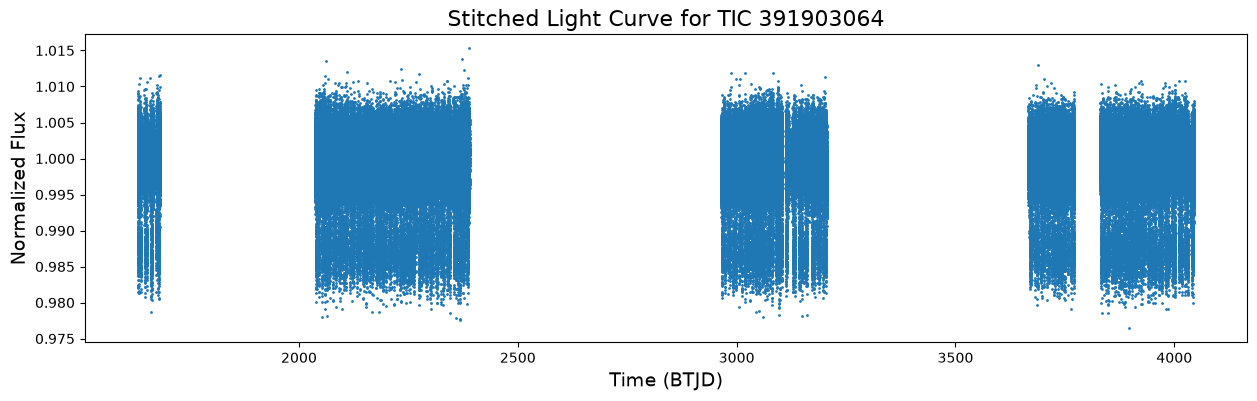

In [8]:
# plot different sectors of the stitched light curve in different colors

fig, ax = plt.subplots(figsize=(15, 4))

ax.set_title(f'Stitched Light Curve for TIC {tic_ids[0]}', fontsize=16)
ax.set_xlabel('Time (BTJD)', fontsize=14)
ax.set_ylabel('Normalized Flux', fontsize=14)
ax.plot(lc_collection_1.time.value, lc_collection_1.flux.value, '.', markersize=2)


# lc_collection.plot(label='Stitched Light Curve')
# # remove the legend to avoid cluttering the plot
# plt.legend().remove()
plt.show()

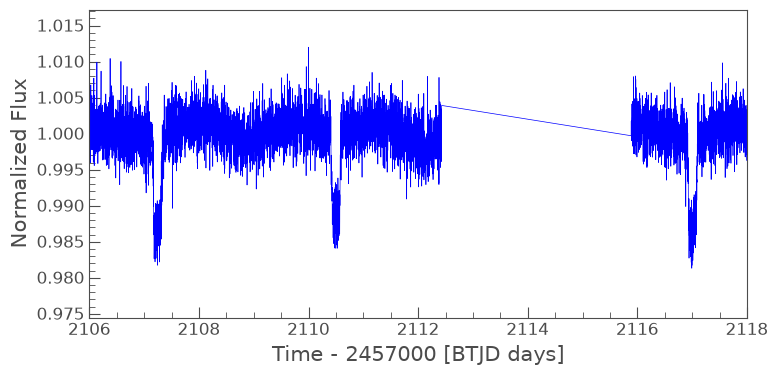

In [19]:

lc_collection_1.plot(label='Stitched Light Curve', color='blue')
# remove the legend to avoid cluttering the plot
plt.legend().remove()
plt.xlim(2106, 2118)
plt.show()

In [17]:
lc1 = lc_collection[0]
# make lc2 with time 1320 to 1400  
lc2 = lc1[(lc1.time.value >= 1320) & (lc1.time.value <= 1400)]
lc2

# derive period and t0 from the exoplanet archive data
period = exo_archive[exo_archive['tid'] == tic_id_adopted]
period = period['pl_orbper'].values
# t0 = exo_archive_CP[exo_archive_CP['tid'] == tic_ids[0]]
# t0 = t0['epoch'].values[0]
print(f"Period: {period}")

# lc2.plot(label='Stitched Light Curve')
# plt.show()

Period: [3.2541181]


In [18]:
lc1[np.argmax(lc1['flux'])]

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1636.819785667269,3.6228608e+03,8.9002514e+00,-8.1532140e-04,294743,708.49111,745.76482,3.2292695e+03,7.5669794e+00,8.4367798e+02,2.7758546e+00,3.6228608e+03,8.9002514e+00,0,———,———,———,———,708.49111,1.8008499e-03,745.76482,1.7286300e-03,7.5989314e-03,-6.4636911e-03


Best Period from BLS: 3.2564256425642566 d


/tmp/ipykernel_7932/3401636739.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d
Best Period from BLS: 3.2564256425642566 d


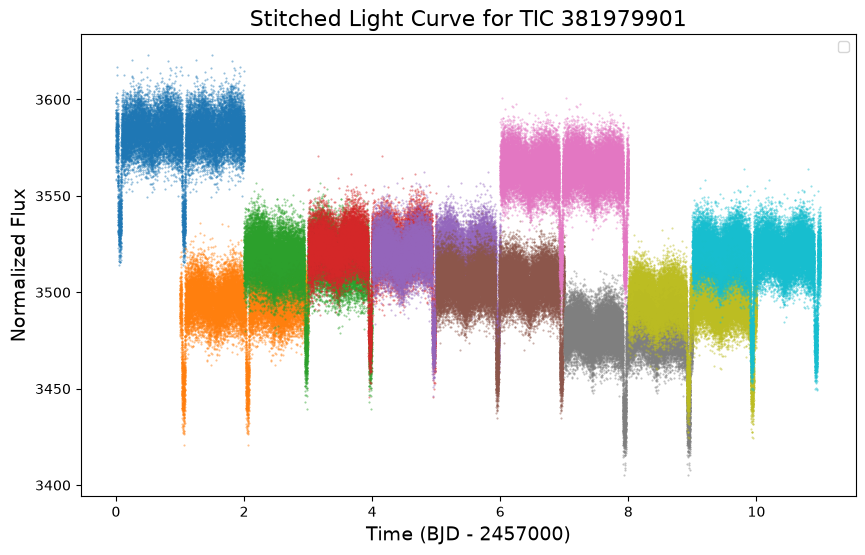

In [19]:
fig = plt.subplots(figsize=(10, 6))

for i in range(10):
    lc1 = lc_collection[i]
    # make lc2 with time 1320 to 1400  
    lc2 = lc1 #[(lc1.time.value >= 1320) & (lc1.time.value <= 1400)]
    lc2
    # lc2.plot(label='Stitched Light Curve')
    # plt.show()

    # derive period using periodogram
    periodogram = lc2.to_periodogram(method='bls', period=np.linspace(0.5, 100, 10000))
    best_period = periodogram.period_at_max_power
    print(f"Best Period from BLS: {best_period}")

    lc2 =  phase_fold(lc2, period=best_period.value, t0=2460041.17509700)

    plt.errorbar(i+lc2.phase.value, lc2.flux.value, fmt='.', markersize=1, alpha=0.5, color=plt.cm.tab10.colors[i])
    plt.errorbar(i+1+lc2.phase.value, lc2.flux.value, fmt='.', markersize=1, alpha=0.5, color=plt.cm.tab10.colors[i])

    plt.xlabel('Time (BJD - 2457000)', fontsize=14)
    plt.ylabel('Normalized Flux', fontsize=14)
    plt.title(f'Stitched Light Curve for TIC {tic_id_adopted}', fontsize=16)
    plt.legend()
plt.show()


In [23]:
%matplotlib inline

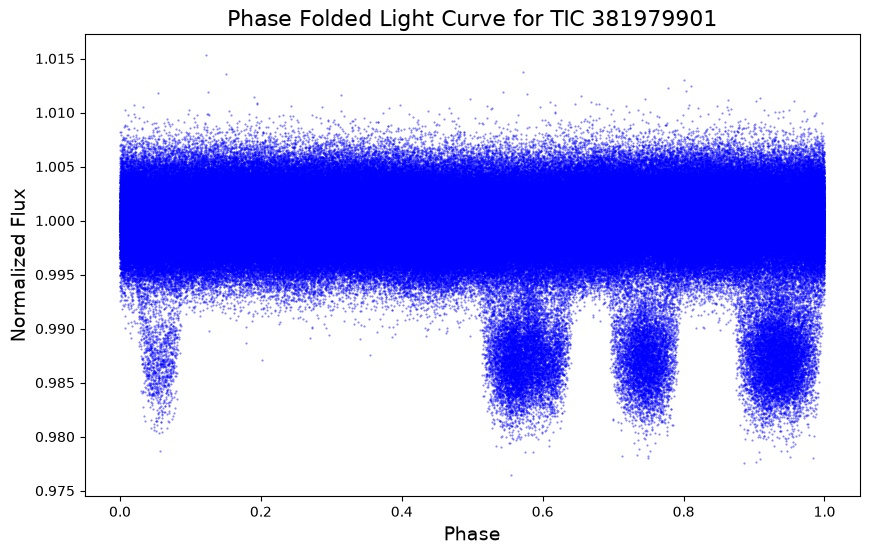

In [24]:
# plot the phase folded light curve for the stitched light curve

plt.figure(figsize=(10, 6))

lc_collection_1 =  phase_fold(lc_collection_1, period=3.2564256425642566, t0=2460041.17509700)
                            #   best_period.value, t0=1602.7229317963508)
plt.errorbar(lc_collection_1.phase.value, lc_collection_1.flux.value, fmt='.', markersize=1, alpha=0.5, color='blue')
plt.xlabel('Phase', fontsize=14)
plt.ylabel('Normalized Flux', fontsize=14)
plt.title(f'Phase Folded Light Curve for TIC {tic_id_adopted}', fontsize=16)
# plt.xlim(-0.5, 0.5)
plt.show()

`period` contains 971777 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


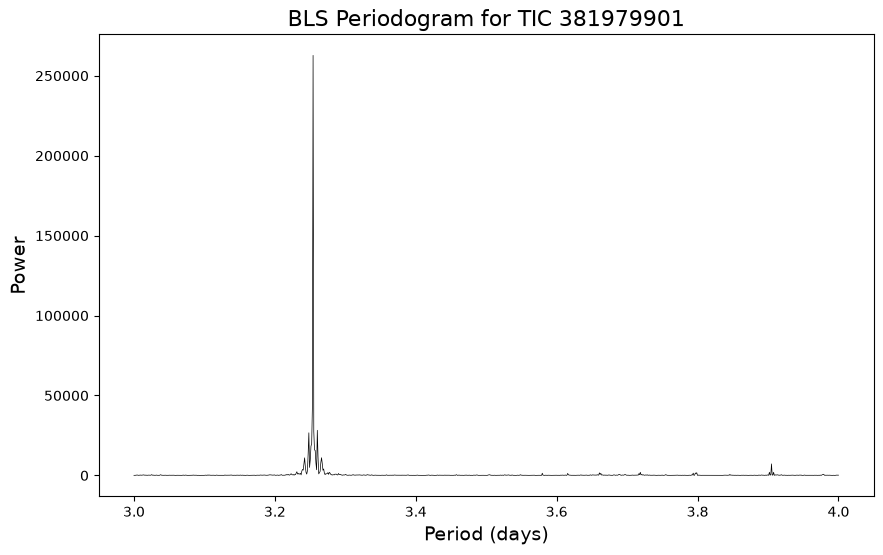

Best period: 3.2542542542542536


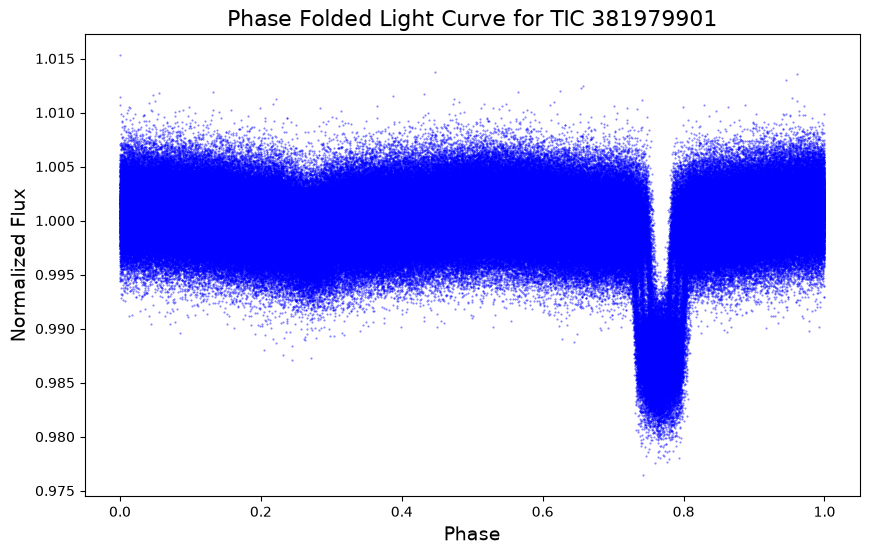

In [25]:
pg = lc_collection_1.to_periodogram(method='bls', period=np.linspace(3, 4, 1000), frequency_factor=10.0)
plt.figure(figsize=(10, 6))
plt.plot(pg.period, pg.power, color='black', lw=0.5)
plt.xlabel('Period (days)', fontsize=14)
plt.ylabel('Power', fontsize=14)
plt.title(f'BLS Periodogram for TIC {tic_id_adopted}', fontsize=16)
plt.show()

best_period = pg.period_at_max_power
print(f'Best period: {best_period.value}')

# plot the phase folded light curve for the stitched light curve

plt.figure(figsize=(10, 6))

lc_collection_1 =  phase_fold(lc_collection_1, period=best_period.value, t0=lc_collection_1.time.value[np.argmax(lc_collection_1.flux.value)])
plt.errorbar(lc_collection_1.phase.value, lc_collection_1.flux.value, fmt='.', markersize=1, alpha=0.5, color='blue')
plt.xlabel('Phase', fontsize=14)
plt.ylabel('Normalized Flux', fontsize=14)
plt.title(f'Phase Folded Light Curve for TIC {tic_id_adopted}', fontsize=16)
# plt.xlim(-0.5, 0.5)
plt.show()

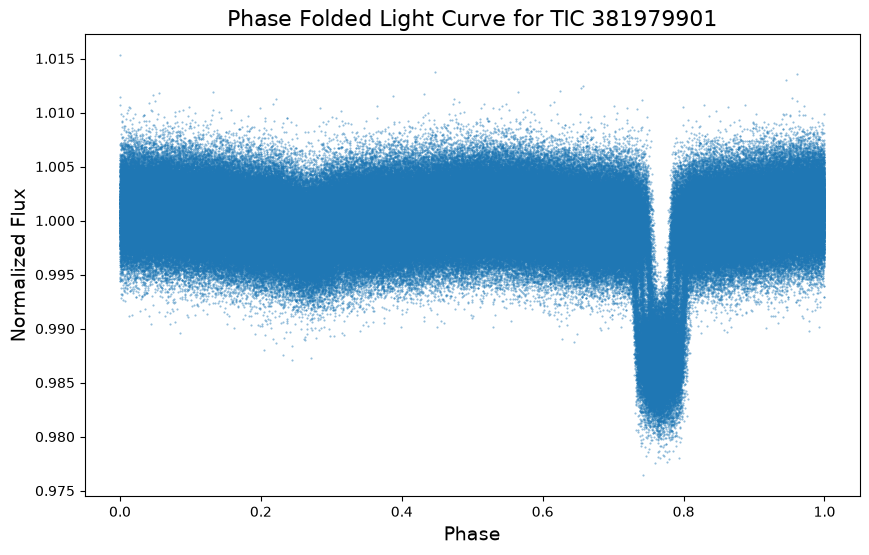

In [26]:

# plot the phase folded light curve for the stitched light curve

plt.figure(figsize=(10, 6))

lc_collection_1 =  phase_fold(lc_collection_1, period=best_period.value, t0=lc_collection_1.time.value[np.argmax(lc_collection_1.flux.value)])
plt.errorbar(lc_collection_1.phase.value, lc_collection_1.flux.value, fmt='.', markersize=1, alpha=0.5)
plt.xlabel('Phase', fontsize=14)
plt.ylabel('Normalized Flux', fontsize=14)
plt.title(f'Phase Folded Light Curve for TIC {tic_id_adopted}', fontsize=16)
# plt.xlim(-0.5, 0.5)
plt.show()


In [16]:
t0_epoch = 2460041.17509700
lc_collection_1

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2,phase
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix,
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float64
1631.1961468450756,9.9882382e-01,2.8635759e-03,-8.4542402e-04,290694,708.49071,745.75911,3.1986743e+03,8.7221966e+00,1.9431851e+03,3.7985125e+00,3.5783745e+03,1.0259014e+01,0,———,———,———,———,708.49071,2.1591643e-03,745.75911,2.0265344e-03,8.8686896e-03,-1.2634297e-02,0.49328188205910806
1631.1975357412314,9.9973518e-01,2.8642570e-03,-8.4541616e-04,290695,708.48587,745.76467,3.2010239e+03,8.7242718e+00,1.9451721e+03,3.8002405e+00,3.5816396e+03,1.0261454e+01,0,———,———,———,———,708.48587,2.1565717e-03,745.76467,2.0232974e-03,2.8846257e-03,-3.8436428e-03,0.4937086760485272
1631.1989246374458,1.0027416e+00,2.8662242e-03,-8.4540824e-04,290696,708.48707,745.75709,3.2114211e+03,8.7302637e+00,1.9383329e+03,3.7972021e+00,3.5924104e+03,1.0268501e+01,0,———,———,———,———,708.48707,2.1503970e-03,745.75709,2.0196158e-03,5.6239455e-03,-1.6499063e-02,0.4941354700559657
1631.200313533661,1.0040792e+00,2.8663042e-03,-8.4540033e-04,290697,708.48636,745.76276,3.2145415e+03,8.7305069e+00,1.9372135e+03,3.7972817e+00,3.5972024e+03,1.0268788e+01,0,———,———,———,———,708.48636,2.1460035e-03,745.76276,2.0184752e-03,6.2254216e-03,-9.5510595e-03,0.4945622640636884
1631.2017024298168,1.0039591e+00,2.8650244e-03,-8.4539247e-04,290698,708.48178,745.76088,3.2134199e+03,8.7266092e+00,1.9319041e+03,3.7912254e+00,3.5967720e+03,1.0264203e+01,0,———,———,———,———,708.48178,2.1489444e-03,745.76088,2.0191779e-03,3.1784435e-03,-1.2125563e-02,0.49498905805307913
1631.2030913260307,9.9952638e-01,2.8654013e-03,-8.4538455e-04,290699,708.48526,745.75873,3.2010720e+03,8.7277575e+00,1.9351871e+03,3.8007443e+00,3.5808916e+03,1.0265553e+01,0,———,———,———,———,708.48526,2.1518727e-03,745.75873,2.0269440e-03,2.9117912e-03,-1.2892405e-02,0.49541585206037553
1631.2044802221874,1.0000404e+00,2.8616295e-03,-8.4537669e-04,290700,708.48668,745.75820,3.2002886e+03,8.7162685e+00,1.9368268e+03,3.7940538e+00,3.5827332e+03,1.0252041e+01,0,———,———,———,———,708.48668,2.1547251e-03,745.75820,2.0245223e-03,3.4499590e-03,-1.4766157e-02,0.4958426460500789
1631.2058691184027,1.0002774e+00,2.8604453e-03,-8.4536878e-04,290701,708.48550,745.76344,3.2035471e+03,8.7126617e+00,1.9315909e+03,3.7880571e+00,3.5835823e+03,1.0247798e+01,0,———,———,———,———,708.48550,2.1522229e-03,745.76344,2.0200054e-03,7.1183341e-03,-8.8019958e-03,0.4962694400578016


In [17]:
"""
data/preprocess.py — Light curve preprocessing wrappers around lightkurve.

Steps:
  1. Remove NaNs
  2. Quality bit masking (applied per sector by lightkurve)
  3. Outlier sigma clipping
  4. Stitch multi-sector collection
  5. Initial flattening / detrending (first-pass only; GP handles residuals)

Returns a single clean lightkurve.LightCurve object normalised to unit flux.
"""

from __future__ import annotations

import warnings
from typing import Any

import numpy as np

from tess_pipeline.exceptions import PreprocessingError
from tess_pipeline.utils.logging import get_logger

log = get_logger(__name__)


def preprocess(
    lc_collection: Any,
    *,
    period: float | None = None,
    epoch: float | None = None,
    transit_mask_width: float = 0.15,
    sigma_clip_lower: float = 20.0,
    sigma_clip_upper: float = 5.0,
    flatten_window_length: int = 401,
    flatten_polyorder: int = 3,
    flatten_break_tolerance: int = 5,
) -> Any:
    """
    Preprocess a ``lightkurve.LightCurveCollection`` into a single
    clean, stitched, and flattened light curve.

    Parameters
    ----------
    lc_collection : lightkurve.LightCurveCollection
    period : float | None
        Orbital period of the planet in days (optional, to construct a transit mask).
    epoch : float | None
        Transit mid-time (optional, to construct a transit mask).
    transit_mask_width : float
        Width (in days) around the transit center to mask out (default: 0.15 days).
    sigma_clip_lower, sigma_clip_upper : float
        Sigma thresholds for outlier removal.
    flatten_window_length : int
        Savitzky-Golay window length in cadences (must be odd).
    flatten_polyorder : int
        Savitzky-Golay polynomial order.
    flatten_break_tolerance : int
        Gap size (cadences) that triggers a new segment in flatten().

    Returns
    -------
    lightkurve.LightCurve
        Normalised, stitched, and flattened light curve.
    """
    try:
        import lightkurve as lk
    except ImportError as exc:
        raise PreprocessingError("lightkurve is required for preprocessing") from exc

    if lc_collection is None or len(lc_collection) == 0:
        raise PreprocessingError("Empty light curve collection; nothing to preprocess.")

    # ── Per-sector: remove NaNs and clip outliers (ignoring transit window if mask is active) ──
    cleaned = []
    for lc in lc_collection:
        lc = lc.remove_nans()

        # Construct a transit mask to protect transit points from clipping
        transit_mask = np.zeros(len(lc), dtype=bool)
        if period is not None:
            t0 = epoch
            if t0 is None:
                t0 = float(lc.time.value[np.argmin(lc.flux.value)])
                log.info("[preprocess] Epoch is None; estimating fallback epoch from flux minimum: %.5f", t0)
            if t0 > 2400000 and np.median(lc.time.value) < 100000:
                t0 -= 2457000.0  # Convert BJD to BTJD if needed
            phase = ((lc.time.value - t0) / period) % 1.0
            phase[phase > 0.5] -= 1.0
            transit_mask = np.abs(phase) < (transit_mask_width / period)

        try:
            if np.any(transit_mask):
                non_transit_indices = np.where(~transit_mask)[0]
                sub_lc = lc[non_transit_indices]
                _, outlier_mask = sub_lc.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                    return_mask=True,
                )
                full_outlier_mask = np.zeros(len(lc), dtype=bool)
                full_outlier_mask[non_transit_indices] = outlier_mask
                lc = lc[~full_outlier_mask]
            else:
                lc = lc.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                )
        except Exception as exc:
            log.warning("Outlier removal failed on sector: %s", exc)

        cleaned.append(lc)

    if not cleaned:
        raise PreprocessingError("All sectors removed after NaN/outlier cleaning.")

    # ── Stitch sectors ────────────────────────────────────────────────────────
    collection = lk.LightCurveCollection(cleaned)
    stitched = collection.stitch()
    log.debug(
        "Stitched %d sectors → %d cadences",
        len(cleaned),
        len(stitched),
    )

    # ── Ensure odd window length ──────────────────────────────────────────────
    if flatten_window_length % 2 == 0:
        flatten_window_length += 1
        log.debug("Adjusted flatten_window_length to %d (must be odd)", flatten_window_length)

    # Re-calculate transit mask on stitched light curve for flattening
    transit_mask_stitched = np.zeros(len(stitched), dtype=bool)
    if period is not None:
        t0 = epoch
        if t0 is None:
            t0 = float(stitched.time.value[np.argmin(stitched.flux.value)])
            log.info("[preprocess] Epoch is None; estimating fallback stitched epoch from flux minimum: %.5f", t0)
        if t0 > 2400000 and np.median(stitched.time.value) < 100000:
            t0 -= 2457000.0
        phase = ((stitched.time.value - t0) / period) % 1.0
        phase[phase > 0.5] -= 1.0
        transit_mask_stitched = np.abs(phase) < (transit_mask_width / period)

    # ── Initial flatten (first-pass detrend) with transit mask ─────────────────
    try:
        flat, trend = stitched.flatten(
            window_length=flatten_window_length,
            polyorder=flatten_polyorder,
            break_tolerance=flatten_break_tolerance,
            mask=transit_mask_stitched if np.any(transit_mask_stitched) else None,
            return_trend=True,
        )
    except Exception as exc:
        log.warning("Flattening failed (%s); using unflattened light curve", exc)
        flat = stitched

    # Final NaN pass and outlier removal after flattening
    flat = flat.remove_nans()
    try:
        if np.any(transit_mask_stitched):
            non_transit_indices = np.where(~transit_mask_stitched)[0]
            sub_flat = flat[non_transit_indices]
            _, outlier_mask = sub_flat.remove_outliers(
                sigma_lower=sigma_clip_lower,
                sigma_upper=sigma_clip_upper,
                return_mask=True,
            )
            full_outlier_mask = np.zeros(len(flat), dtype=bool)
            full_outlier_mask[non_transit_indices] = outlier_mask
            flat = flat[~full_outlier_mask]
        else:
            flat = flat.remove_outliers(
                sigma_lower=sigma_clip_lower,
                sigma_upper=sigma_clip_upper,
            )
    except Exception as exc:
        log.warning("Final outlier removal failed: %s", exc)

    if len(flat) == 0:
        raise PreprocessingError("Light curve is empty after preprocessing.")

    log.info("Preprocessing complete: %d cadences remain", len(flat))
    return flat


In [ ]:
# """
# data/preprocess.py : Light curve preprocessing wrappers around lightkurve.

# Steps:
#   1. Remove NaNs
#   2. Quality bit masking (applied per sector by lightkurve)
#   3. Outlier sigma clipping
#   4. Stitch multi-sector collection
#   5. Initial flattening / detrending (first-pass only; GP handles residuals)

# Returns a single clean lightkurve.LightCurve object normalised to unit flux.
# """

# from __future__ import annotations

# import warnings
# from typing import Any

# import numpy as np
# import matplotlib.pyplot as plt

# from tess_pipeline.exceptions import PreprocessingError
# from tess_pipeline.utils.logging import get_logger

# log = get_logger(__name__)


# def plot_lightcurve_step(lc: Any, title: str, mask: np.ndarray | None = None) -> None:
#     """Helper function to plot a lightkurve object for visual inspection."""
#     plt.figure(figsize=(10, 4))
    
#     # Plot the base light curve
#     lc.scatter(label="Data", alpha=0.5, s=2, color="k")
    
#     # Overlay the masked points if a mask is provided
#     if mask is not None and np.any(mask):
#         masked_lc = lc[mask]
#         plt.scatter(
#             masked_lc.time.value, 
#             masked_lc.flux.value, 
#             color="red", 
#             s=4, 
#             label="In-Transit Mask", 
#             zorder=5
#         )
        
#     plt.title(title)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# def preprocess(
#     lc_collection: Any,
#     *,
#     period: float | None = None,
#     epoch: float | None = None,
#     transit_mask_width: float = 0.15,
#     sigma_clip_lower: float = 20.0,
#     sigma_clip_upper: float = 5.0,
#     flatten_window_length: int = 401,
#     flatten_polyorder: int = 3,
#     flatten_break_tolerance: int = 5,
#     visualize: bool = False,
# ) -> Any:
#     """
#     Preprocess a ``lightkurve.LightCurveCollection`` into a single
#     clean, stitched, and flattened light curve.
#     """
#     try:
#         import lightkurve as lk
#     except ImportError as exc:
#         raise PreprocessingError("lightkurve is required for preprocessing") from exc

#     if lc_collection is None or len(lc_collection) == 0:
#         raise PreprocessingError("Empty light curve collection; nothing to preprocess.")

#     # Step 1: Per-sector cleaning and masking
#     cleaned = []
#     for i, lc in enumerate(lc_collection):
#         lc = lc.remove_nans()
#         sector_name = getattr(lc, "sector", f"Index {i}")

#         if visualize:
#             plot_lightcurve_step(lc, f"Sector {sector_name}: Raw (NaNs Removed)")

#         transit_mask = np.zeros(len(lc), dtype=bool)
#         if period is not None:
#             t0 = epoch
#             if t0 is None:
#                 t0 = float(lc.time.value[np.argmin(lc.flux.value)])
#                 log.info("[preprocess] Epoch is None; estimating fallback epoch from flux minimum: %.5f", t0)
#             if t0 > 2400000 and np.median(lc.time.value) < 100000:
#                 t0 -= 2457000.0  
#             phase = ((lc.time.value - t0) / period) % 1.0
#             phase[phase > 0.5] -= 1.0
#             transit_mask = np.abs(phase) < (transit_mask_width / period)
            
#             if visualize and np.any(transit_mask):
#                 plot_lightcurve_step(lc, f"Sector {sector_name}: Transit Mask Overlay", mask=transit_mask)

#         try:
#             if np.any(transit_mask):
#                 non_transit_indices = np.where(~transit_mask)[0]
#                 sub_lc = lc[non_transit_indices]
#                 _, outlier_mask = sub_lc.remove_outliers(
#                     sigma_lower=sigma_clip_lower,
#                     sigma_upper=sigma_clip_upper,
#                     return_mask=True,
#                 )
#                 full_outlier_mask = np.zeros(len(lc), dtype=bool)
#                 full_outlier_mask[non_transit_indices] = outlier_mask
#                 lc = lc[~full_outlier_mask]
#             else:
#                 lc = lc.remove_outliers(
#                     sigma_lower=sigma_clip_lower,
#                     sigma_upper=sigma_clip_upper,
#                 )
#         except Exception as exc:
#             log.warning("Outlier removal failed on sector: %s", exc)

#         if visualize:
#             # We recalculate a quick mask just for the plot after clipping out data points
#             plot_mask = None
#             if period is not None and np.any(transit_mask):
#                 phase = ((lc.time.value - t0) / period) % 1.0
#                 phase[phase > 0.5] -= 1.0
#                 plot_mask = np.abs(phase) < (transit_mask_width / period)
#             plot_lightcurve_step(lc, f"Sector {sector_name}: After Outlier Clipping", mask=plot_mask)

#         cleaned.append(lc)

#     if not cleaned:
#         raise PreprocessingError("All sectors removed after NaN/outlier cleaning.")

#     # Step 2: Stitch sectors
#     collection = lk.LightCurveCollection(cleaned)
#     stitched = collection.stitch()
#     log.debug("Stitched %d sectors -> %d cadences", len(cleaned), len(stitched))

#     if flatten_window_length % 2 == 0:
#         flatten_window_length += 1
#         log.debug("Adjusted flatten_window_length to %d (must be odd)", flatten_window_length)

#     transit_mask_stitched = np.zeros(len(stitched), dtype=bool)
#     if period is not None:
#         t0 = epoch
#         if t0 is None:
#             t0 = float(stitched.time.value[np.argmin(stitched.flux.value)])
#         if t0 > 2400000 and np.median(stitched.time.value) < 100000:
#             t0 -= 2457000.0
#         phase = ((stitched.time.value - t0) / period) % 1.0
#         phase[phase > 0.5] -= 1.0
#         transit_mask_stitched = np.abs(phase) < (transit_mask_width / period)
        
#     if visualize:
#         plot_lightcurve_step(stitched, "Stitched Light Curve (All Sectors)", mask=transit_mask_stitched)

#     # Step 3: Initial flatten
#     try:
#         flat, trend = stitched.flatten(
#             window_length=flatten_window_length,
#             polyorder=flatten_polyorder,
#             break_tolerance=flatten_break_tolerance,
#             mask=transit_mask_stitched if np.any(transit_mask_stitched) else None,
#             return_trend=True,
#         )
        
#         if visualize:
#             plt.figure(figsize=(10, 4))
#             ax = stitched.scatter(label="Stitched Data", alpha=0.5, s=2, color="k")
#             if np.any(transit_mask_stitched):
#                 masked_stitched = stitched[transit_mask_stitched]
#                 plt.scatter(masked_stitched.time.value, masked_stitched.flux.value, color="red", s=4, label="In-Transit Mask", zorder=5)
#             trend.plot(ax=ax, color="blue", lw=2, label="Savitzky-Golay Trend")
#             plt.title("Stitched Light Curve with Detrending Trendline")
#             plt.legend()
#             plt.tight_layout()
#             plt.show()
            
#     except Exception as exc:
#         log.warning("Flattening failed (%s); using unflattened light curve", exc)
#         flat = stitched

#     # Final cleanup
#     flat = flat.remove_nans()
#     try:
#         if np.any(transit_mask_stitched):
#             non_transit_indices = np.where(~transit_mask_stitched)[0]
#             sub_flat = flat[non_transit_indices]
#             _, outlier_mask = sub_flat.remove_outliers(
#                 sigma_lower=sigma_clip_lower,
#                 sigma_upper=sigma_clip_upper,
#                 return_mask=True,
#             )
#             full_outlier_mask = np.zeros(len(flat), dtype=bool)
#             full_outlier_mask[non_transit_indices] = outlier_mask
#             flat = flat[~full_outlier_mask]
#         else:
#             flat = flat.remove_outliers(
#                 sigma_lower=sigma_clip_lower,
#                 sigma_upper=sigma_clip_upper,
#             )
#     except Exception as exc:
#         log.warning("Final outlier removal failed: %s", exc)

#     if len(flat) == 0:
#         raise PreprocessingError("Light curve is empty after preprocessing.")

#     if visualize:
#         plot_lightcurve_step(flat, "Final Output: Flattened and Cleaned Light Curve")

#     log.info("Preprocessing complete: %d cadences remain", len(flat))
#     return flat

In [ ]:
# lc_collection_2 = preprocess(
#     lc_collection,
#     period=best_period.value,
#     epoch=lc_collection_1.time.value[np.argmin(lc_collection_1.flux.value)],
#     transit_mask_width=0.15,
#     sigma_clip_lower=20.0,
#     sigma_clip_upper=5.0,
#     flatten_window_length=401,
#     flatten_polyorder=3,
#     flatten_break_tolerance=5,
#     visualize=True
# )

### Per sector detrending and then stitching 

In [9]:
"""
data/preprocess.py : Light curve preprocessing wrappers around lightkurve.

Steps:
  1. Remove NaNs
  2. Quality bit masking (applied per sector by lightkurve)
  3. Outlier sigma clipping (Per Sector)
  4. Initial flattening / detrending (Per Sector)
  5. Stitch multi-sector collection
  6. Generate and save diagnostic plots

Returns a single clean lightkurve.LightCurve object normalised to unit flux.
"""

from __future__ import annotations

import os
import warnings
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

from tess_pipeline.exceptions import PreprocessingError
from tess_pipeline.utils.logging import get_logger

log = get_logger(__name__)


def preprocess(
    lc_collection: Any,
    *,
    period: float | None = None,
    epoch: float | None = None,
    transit_mask_width: float | None = None,
    sigma_clip_lower: float = 20.0,
    sigma_clip_upper: float = 5.0,
    flatten_window_length: int = 401,
    flatten_polyorder: int = 3,
    flatten_break_tolerance: int = 5,
    visualize: bool = False,
    save_plots: bool = True,
    output_dir: str = "preprocessing_plots",
) -> Any:
    """
    Preprocess a ``lightkurve.LightCurveCollection`` into a single
    clean, stitched, and flattened light curve.

    Parameters
    ----------
    lc_collection : Any
        A lightkurve.LightCurveCollection object containing the unstitched, raw observational data segments to be processed.
    period : float | None
        A float defining the orbital period of the target exoplanet in days. This is used to calculate the orbital 
        phase and generate a mask over the transits.
    epoch : float | None
        A float defining the transit mid-time reference point. If this is missing but a period is provided, the 
        script will attempt to guess the epoch using the timestamp of the lowest flux value in the dataset.
    transit_mask_width : float | None
        A float representing the total time window (in days) centered on the epoch that will be masked out. 
        If None and a period is provided, this scales automatically as 0.12 * P^(1/3). 
        If None and no period is provided, it falls back to 0.15 days.
    sigma_clip_lower : float
        A float determining the statistical threshold (in standard deviations) for rejecting negative flux anomalies. 
    sigma_clip_upper : float
        A float determining the statistical threshold for rejecting positive flux anomalies.
    flatten_window_length : int
        An integer specifying the number of cadences included in the moving window of the Savitzky-Golay filter. 
    flatten_polyorder : int
        An integer specifying the degree of the polynomial used within the Savitzky-Golay window.
    flatten_break_tolerance : int
        An integer defining the threshold for data gaps.
    visualize : bool
        A boolean flag. When set to True, the script will display the plots directly in the notebook or window.
    save_plots : bool
        A boolean flag. When set to True, the script saves all sector and final plots to the output directory.
    output_dir : str
        The folder path where diagnostic plots will be saved. Defaults to 'preprocessing_plots'.

    Returns
    -------
    lightkurve.LightCurve
        Normalised, stitched, and flattened light curve.
    """
    try:
        import lightkurve as lk
    except ImportError as exc:
        raise PreprocessingError("lightkurve is required for preprocessing") from exc

    if lc_collection is None or len(lc_collection) == 0:
        raise PreprocessingError("Empty light curve collection; nothing to preprocess.")

    # Create the output directory if plotting is enabled
    if save_plots:
        os.makedirs(output_dir, exist_ok=True)
        log.info("Saving diagnostic plots to directory: %s", output_dir)

    # Calculate dynamic mask width if not provided
    if transit_mask_width is None:
        if period is not None:
            transit_mask_width = 0.12 * (period ** (1.0 / 3.0))
            log.info("Dynamic mask width calculated: %.3f days for P = %.2f d", transit_mask_width, period)
        else:
            transit_mask_width = 0.15
            log.info("No period or mask width provided; falling back to default 0.15 days.")

    # Ensure odd window length for the Savitzky-Golay filter
    if flatten_window_length % 2 == 0:
        flatten_window_length += 1
        log.debug("Adjusted flatten_window_length to %d (must be odd)", flatten_window_length)

    cleaned_and_flat = []
    trends_list = []
    
    # Step 1 & 2: Per-sector cleaning, masking, and flattening
    for i, lc in enumerate(lc_collection):
        lc = lc.remove_nans()
        sector_name = getattr(lc, "sector", f"Index_{i}")

        # Create transit mask for clipping and flattening
        transit_mask = np.zeros(len(lc), dtype=bool)
        if period is not None:
            t0 = epoch
            if t0 is None:
                t0 = float(lc.time.value[np.argmin(lc.flux.value)])
            if t0 > 2400000 and np.median(lc.time.value) < 100000:
                t0 -= 2457000.0  
            phase = ((lc.time.value - t0) / period) % 1.0
            phase[phase > 0.5] -= 1.0
            transit_mask = np.abs(phase) < (transit_mask_width / period)
            
        # Initial Outlier Clipping
        try:
            if np.any(transit_mask):
                non_transit_indices = np.where(~transit_mask)[0]
                sub_lc = lc[non_transit_indices]
                _, outlier_mask = sub_lc.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                    return_mask=True,
                )
                full_outlier_mask = np.zeros(len(lc), dtype=bool)
                full_outlier_mask[non_transit_indices] = outlier_mask
                lc = lc[~full_outlier_mask]
                transit_mask = transit_mask[~full_outlier_mask]
            else:
                lc = lc.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                )
        except Exception as exc:
            log.warning("Outlier removal failed on sector: %s", exc)

        # Retain a copy of the pre-flattened light curve for plotting
        lc_pre_flat = lc.copy()

        # Flattening (Per-Sector Detrending)
        try:
            flat, trend = lc.flatten(
                window_length=flatten_window_length,
                polyorder=flatten_polyorder,
                break_tolerance=flatten_break_tolerance,
                mask=transit_mask if np.any(transit_mask) else None,
                return_trend=True,
            )
            lc = flat
            trends_list.append(trend)
        except Exception as exc:
            log.warning("Flattening failed (%s) on sector %s; using unflattened light curve", exc, sector_name)
            dummy_trend = lc.copy()
            dummy_trend.flux = np.ones_like(lc.flux.value)
            trends_list.append(dummy_trend)
            trend = dummy_trend

        # Final NaN pass and outlier removal after flattening
        lc = lc.remove_nans()
        
        final_mask = np.zeros(len(lc), dtype=bool)
        if period is not None:
            phase = ((lc.time.value - t0) / period) % 1.0
            phase[phase > 0.5] -= 1.0
            final_mask = np.abs(phase) < (transit_mask_width / period)

        try:
            if np.any(final_mask):
                non_transit_indices = np.where(~final_mask)[0]
                sub_flat = lc[non_transit_indices]
                _, outlier_mask = sub_flat.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                    return_mask=True,
                )
                full_outlier_mask = np.zeros(len(lc), dtype=bool)
                full_outlier_mask[non_transit_indices] = outlier_mask
                lc = lc[~full_outlier_mask]
            else:
                lc = lc.remove_outliers(
                    sigma_lower=sigma_clip_lower,
                    sigma_upper=sigma_clip_upper,
                )
        except Exception as exc:
            log.warning("Final outlier removal failed on sector %s: %s", sector_name, exc)

        cleaned_and_flat.append(lc)

        # Plot Sector Results
        if visualize or save_plots:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
            
            # Top Panel: Raw + Trend + Mask
            ax1.plot(lc_pre_flat.time.value, lc_pre_flat.flux.value, "k.", alpha=0.4, label="Pre-trend Data")
            if np.any(transit_mask):
                masked_lc = lc_pre_flat[transit_mask]
                ax1.plot(masked_lc.time.value, masked_lc.flux.value, "r.", alpha=0.8, label="Transit Mask")
            ax1.plot(trend.time.value, trend.flux.value, "C0-", lw=2, label="Savitzky-Golay Trend")
            
            ax1.set_ylabel("Flux")
            ax1.set_title(f"Sector {sector_name} Detrending")
            ax1.legend(loc="upper right")
            
            # Bottom Panel: Flattened Data
            ax2.plot(lc.time.value, lc.flux.value, "C1.", alpha=0.8, label="Flattened Data")
            ax2.axhline(1.0, color="k", ls="--", lw=1)
            ax2.set_xlabel("Time")
            ax2.set_ylabel("Normalized Flux")
            ax2.legend(loc="upper right")
            
            plt.tight_layout()
            
            if save_plots:
                sector_plot_path = os.path.join(output_dir, f"sector_{sector_name}_processing.png")
                plt.savefig(sector_plot_path, dpi=300, bbox_inches="tight")
                
            if visualize:
                plt.show()
            else:
                plt.close(fig)

    if not cleaned_and_flat:
        raise PreprocessingError("All sectors removed after NaN/outlier cleaning.")

    # Step 3: Stitch the independently flattened sectors together
    collection = lk.LightCurveCollection(cleaned_and_flat)
    stitched = collection.stitch()
    log.debug("Stitched %d sectors -> %d cadences", len(cleaned_and_flat), len(stitched))

    if len(stitched) == 0:
        raise PreprocessingError("Light curve is empty after preprocessing.")

    log.info("Preprocessing complete: %d cadences remain", len(stitched))

    # Step 4: Final 4:1 Visualization
    if visualize or save_plots:
        # Reconstruct a raw stitched curve for comparison
        raw_list = [raw_lc.remove_nans().normalize() for raw_lc in lc_collection]
        raw_stitched = lk.LightCurveCollection(raw_list).stitch()
        
        # Stitch the trendlines generated during the loop
        trend_stitched = lk.LightCurveCollection(trends_list).stitch()

        fig = plt.figure(figsize=(12, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.05)
        
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax1)

        # Top Panel: Raw vs Processed Overlay with Trend
        ax1.plot(raw_stitched.time.value, raw_stitched.flux.value, "k.", alpha=0.3, markersize=3, label="Raw (Normalized)")
        ax1.plot(trend_stitched.time.value, trend_stitched.flux.value, "C0-", lw=1.5, label="Savitzky-Golay Trend", zorder=5)
        ax1.plot(stitched.time.value, stitched.flux.value, "C1.", alpha=0.8, markersize=3, label="Processed (Flattened)")
        
        ax1.set_ylabel("Normalized Flux")
        ax1.legend(loc="upper right")
        ax1.set_title("Light Curve Preprocessing: Final Stitched Overview")
        
        # Hide top x-axis labels to avoid clutter
        plt.setp(ax1.get_xticklabels(), visible=False)

        # Bottom Panel: Difference / Residual
        processed_interp = np.interp(raw_stitched.time.value, stitched.time.value, stitched.flux.value)
        residual = raw_stitched.flux.value - processed_interp
        
        ax2.plot(raw_stitched.time.value, residual, "k.", alpha=0.3, markersize=3)
        ax2.axhline(0, color="C1", ls="--", lw=1.5)
        ax2.set_xlabel("Time")
        ax2.set_ylabel("Difference")

        
        if save_plots:
            final_plot_path = os.path.join(output_dir, "final_stitched_preprocessing.png")
            plt.savefig(final_plot_path, dpi=300, bbox_inches="tight")
            log.info("Saved final stitched visualization to %s", final_plot_path)
            
        if visualize:
            plt.show()
        else:
            plt.close(fig)

    return stitched

In [10]:
lc_collection_sector_2 = lc_collection[0:3]  # Example: selecting the first two sectors for demonstration
lc_collection_sector_2

LightCurveCollection of 3 objects:
    0: <TessLightCurve LABEL="TIC 381979901" SECTOR=12 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 381979901" SECTOR=13 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 381979901" SECTOR=27 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

In [31]:
# exo_archive

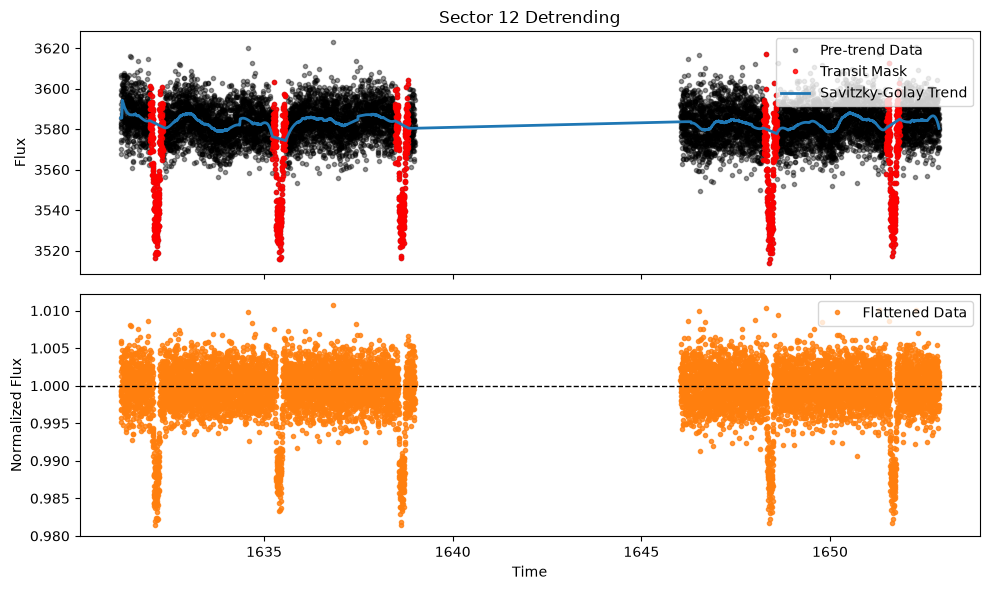

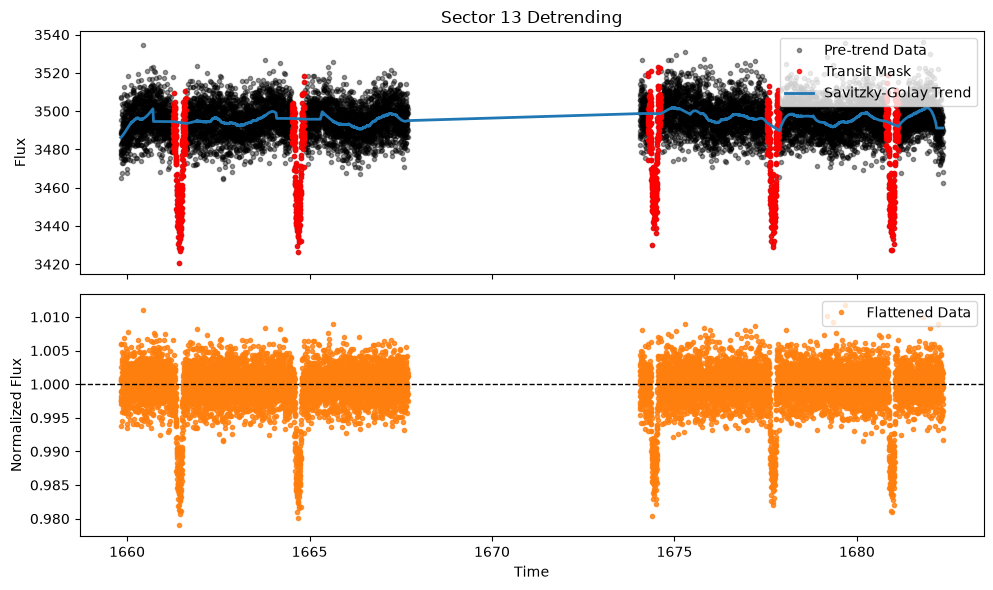

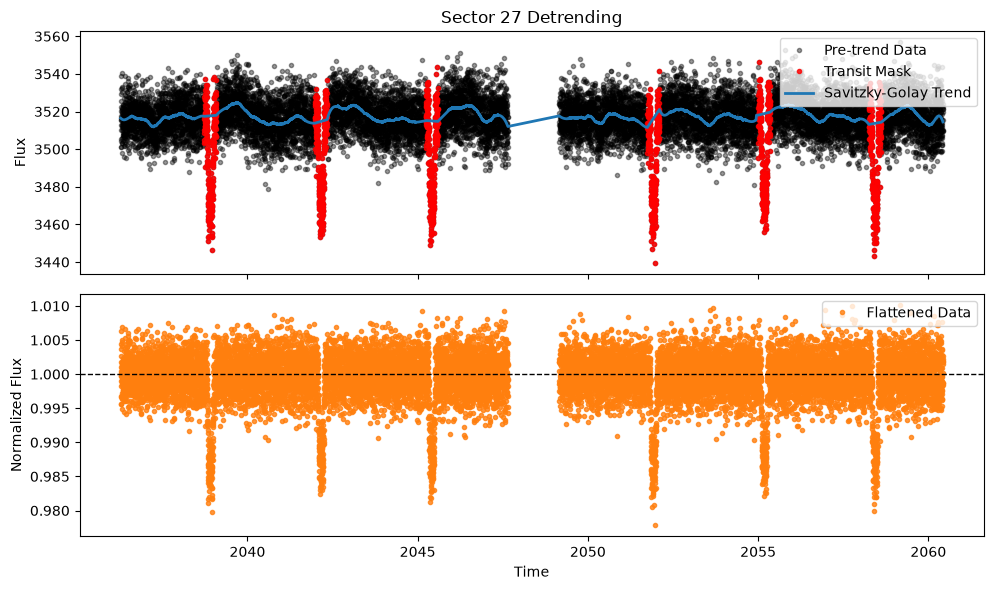

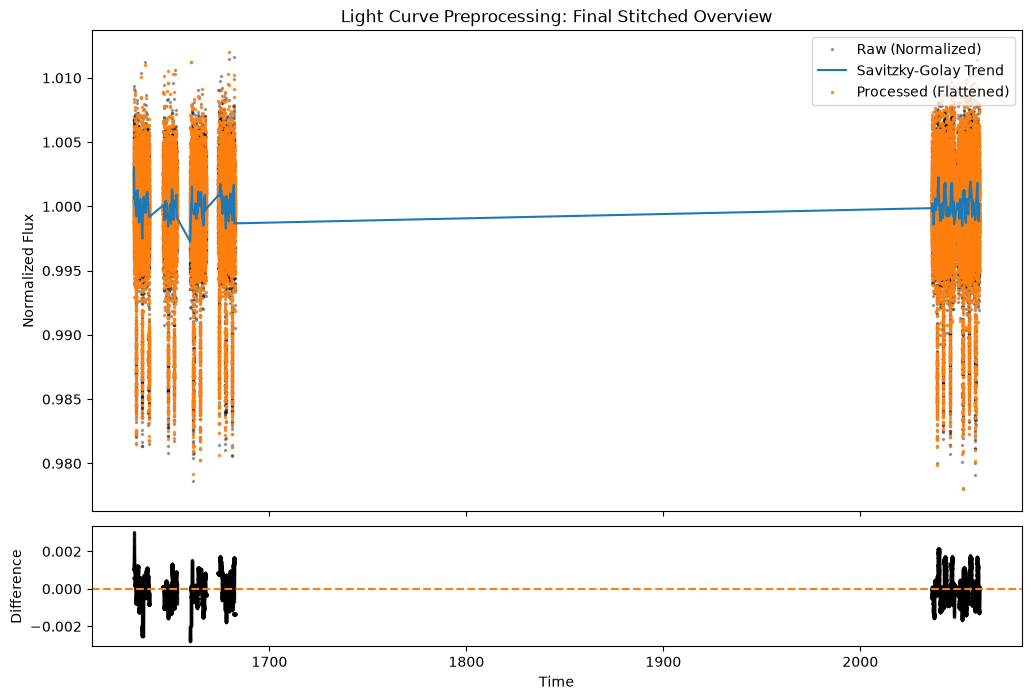

In [20]:
%matplotlib inline

t0_epoch = 2460041.17509700

lc_collection_2 = preprocess(
    lc_collection_sector_2,
    period=period,
    epoch=t0_epoch,
    transit_mask_width=None,  # Let the function calculate a dynamic mask width based on the period
    sigma_clip_lower=20.0,
    sigma_clip_upper=5.0,
    flatten_window_length=401,
    flatten_polyorder=3,
    flatten_break_tolerance=5,
    visualize=True, 
    output_dir = f'data/preprocessing_plots/TIC_{tic_id_adopted}/'
)

In [ ]:
# lc_collection_1 = lc_collection.stitch().remove_nans()


In [ ]:
# # interactive matplotlib plot to compare the original stitched light curve and the preprocessed stitched light curve
# # %matplotlib qt


# fig = plt.Figure(figsize=(20, 6))
# plt.plot(lc_collection_1.time.value, lc_collection_1.flux.value, '.-', markersize=1, alpha=0.7, label='Original Stitched Light Curve')
# plt.plot(lc_collection_2.time.value, lc_collection_2.flux.value, ':', markersize=1, alpha=0.7, label='Preprocessed Stitched Light Curve')
# plt.xlabel('Time (BJD - 2457000)', fontsize=14)
# # plt.xlim(2107, 2108)
# plt.legend()
# plt.show()

In [ ]:
tic_id_adopted

381979901

## PERIOD SEARCH SECTION

In [ ]:
# """Archive period lookup and TLS/BLS period search."""

# from __future__ import annotations

# from typing import TYPE_CHECKING, Any

# from tess_pipeline.utils.logging import get_logger

# if TYPE_CHECKING:
#     from tess_pipeline.config import PipelineConfig
#     from tess_pipeline.results import PipelineResults

# log = get_logger(__name__)


# class PeriodStage:
#     """Look up a known period and/or run TLS/BLS detection."""

#     def __init__(self, config: PipelineConfig, results: PipelineResults) -> None:
#         self.config = config
#         self.results = results
#         self.archive_period: float | None = None
#         self.archive_periods: list[dict[str, Any]] = []

#     def lookup_archive(self) -> float | None:
#         """Query NASA Exoplanet Archive or use a configured period override."""
#         cfg = self.config
#         tic_id = self.results.target["tic_id"]

#         if cfg.period_override is not None:
#             log.info("Using overridden period: %.6f d", cfg.period_override)
#             self.archive_period = cfg.period_override
#             self.archive_periods = [{
#                 "period": cfg.period_override,
#                 "epoch": None,
#                 "source": "override"
#             }]
#             self.results.period = {"value": self.archive_period, "source": "override"}
#             return self.archive_period

#         log.info("Querying NASA Exoplanet Archive for TIC %s", tic_id)
#         from tess_pipeline.catalogs.nasa_archive import query_archive_all

#         archive_results = query_archive_all(tic_id)
#         if archive_results:
#             self.archive_periods = archive_results
#             self.archive_period = archive_results[0]["period"]
#             self.results.period = {
#                 "value": self.archive_period,
#                 "source": "archive",
#                 "reference": archive_results[0].get("reference", ""),
#                 "epoch": archive_results[0].get("epoch"),
#                 "all_periods": [r["period"] for r in archive_results]
#             }
#             log.info(
#                 "Archive periods found: %d planets (Primary: %.6f d)",
#                 len(archive_results),
#                 self.archive_period,
#             )
            
#             # Dynamically adjust max_planets if it's smaller than the archive list
#             from tess_pipeline.constants import DEFAULT_MAX_PLANETS
#             if cfg.max_planets == DEFAULT_MAX_PLANETS and len(archive_results) > DEFAULT_MAX_PLANETS:
#                 log.info("No max_planets provided; defaulting to number of literature entries (%d)", len(archive_results))
#                 cfg.max_planets = len(archive_results)
#             elif cfg.max_planets < len(archive_results):
#                 log.info("Increasing max_planets from %d to %d to accommodate all literature entries", cfg.max_planets, len(archive_results))
#                 cfg.max_planets = len(archive_results)
                
#         return self.archive_period

#     def search(self) -> dict[str, Any]:
#         """Run TLS/BLS period search (support multiple planets)."""
#         cfg = self.config
#         lc = self.results.lightcurve
#         if lc is None:
#             raise RuntimeError("Call load_lightcurves() and preprocess() before search_period()")

#         from tess_pipeline.transit.detection import search_multiple_planets, search_period
#         import numpy as np

#         detections = []

#         if self.archive_periods:
#             is_override = (self.results.period.get("source") == "override")
#             masked_lc = lc.copy()
            
#             for i, arch in enumerate(self.archive_periods):
#                 p_arch = arch["period"]
#                 log.info("%s period found for Planet %d: %.6f d; refining...", 
#                          "Override" if is_override else "Archive", i + 1, p_arch)
#                 try:
#                     half_width = min(0.01, p_arch * 0.002)
#                     search_min = max(cfg.period_min, p_arch - half_width)
#                     search_max = min(cfg.period_max, p_arch + half_width)

#                     det = search_period(
#                         masked_lc,
#                         method=cfg.search_method,
#                         period_min=search_min,
#                         period_max=search_max,
#                         stellar=None,
#                         is_archive=True,
#                     )
#                     if is_override:
#                         det["period"] = p_arch
#                         det["method"] = "override"
#                         det["note"] = "user override preserved"
#                     else:
#                         det["note"] = "refined archive period"
#                 except Exception as exc:
#                     log.warning("Refinement of archive/override period failed: %s", exc)
#                     det = {
#                         "period": p_arch,
#                         "epoch": arch.get("epoch") or float(masked_lc.time.value[np.argmin(masked_lc.flux.value)]),
#                         "duration_hr": 3.0,
#                         "depth": float(1.0 - np.percentile(masked_lc.flux.value, 1)),
#                         "method": "override" if is_override else "archive",
#                         "sde": 10.0,
#                         "snr": 10.0,
#                         "note": "override fallback" if is_override else "archive fallback",
#                     }
#                 detections.append(det)
                
#                 # Mask this planet specifically
#                 period = det["period"]
#                 t0 = det["epoch"]
#                 duration_days = (det["duration_hr"] or 3.0) / 24.0
#                 times = masked_lc.time.value
#                 phase = (times - t0 + 0.5 * period) % period - 0.5 * period
#                 in_transit = np.abs(phase) < (0.75 * duration_days)
                
#                 masked_lc = masked_lc[~in_transit]
                
#             # Now search for any extra planets using the fully masked lightcurve
#             remaining_planets_to_find = cfg.max_planets - len(self.archive_periods)
#             if remaining_planets_to_find > 0:
#                 log.info("Searching for %d additional planet(s) in residuals...", remaining_planets_to_find)
#                 extra_dets = search_multiple_planets(
#                     masked_lc,
#                     method=cfg.search_method,
#                     period_min=cfg.period_min,
#                     period_max=cfg.period_max,
#                     stellar=None,
#                     max_planets=remaining_planets_to_find,
#                 )
#                 detections.extend(extra_dets)
#         else:
#             # No archive period, search all planets from scratch
#             detections = search_multiple_planets(
#                 lc,
#                 method=cfg.search_method,
#                 period_min=cfg.period_min,
#                 period_max=cfg.period_max,
#                 stellar=None,
#                 max_planets=cfg.max_planets,
#             )

#         # Store detections in results
#         self.results.metadata["detections"] = detections
#         if detections:
#             self.results.detection = detections[0]
#             self.results.period = {
#                 "value": detections[0]["period"],
#                 "source": detections[0]["method"],
#             }
#             if self.archive_period is not None:
#                 self.results.period["source"] = "override" if is_override else "archive"
#             log.info("Detections completed. Found %d planet candidate(s).", len(detections))
#         else:
#             raise RuntimeError("No period search detections were found.")

#         return self.results.detection

#     @property
#     def best_period(self) -> float:
#         if not self.results.period:
#             raise RuntimeError("No period available; run lookup_archive() or search() first")
#         return self.results.period["value"]


## TLS

In [12]:
import numpy as np

from transitleastsquares import transitleastsquares
from transitleastsquares.core import fold
import transitleastsquares.tls_constants as tls_constants
import transitleastsquares.stats as tls_stats
import transitleastsquares.main as tls_main


def optimized_final_T0_fit(
    signal,
    depth,
    t,
    y,
    dy,
    period,
    T0_fit_margin=0.0,
    show_progress_bar=False,
    verbose=False,
):
    """
    Optimized replacement for
    transitleastsquares.stats.final_T0_fit().

    Uses a coarse-to-fine search for the transit epoch (T0),
    reducing the computational cost by roughly two orders of
    magnitude while producing essentially identical results.
    """

    dur = len(signal)

    scale = tls_constants.SIGNAL_DEPTH / (1.0 - depth)
    signal = 1.0 - ((1.0 - signal) / scale)

    cadence = float(np.median(np.diff(t)))
    transit_duration = dur * cadence

    # ---------------------------------------------------------
    # Coarse search
    # ---------------------------------------------------------

    coarse_step = 0.30 * transit_duration

    n_coarse = int(np.ceil(period / coarse_step))
    n_coarse = max(100, min(3000, n_coarse))

    T0_coarse = np.linspace(
        np.min(t),
        np.min(t) + period,
        n_coarse,
    )

    if verbose:
        print(f"Coarse T0 search ({n_coarse} points)")

    residual_best = np.inf
    T0_best = None

    signal_ootr = np.ones(len(y[dur:]))

    for Tx in T0_coarse:

        phases = fold(time=t, period=period, T0=Tx)

        idx = np.argsort(phases, kind="mergesort")

        flux = y[idx]
        err = dy[idx]

        roll = int(dur / 2) + 1

        flux = np.concatenate(
            [flux[-roll:], flux[:-roll]]
        )

        err = np.concatenate(
            [err[-roll:], err[:-roll]]
        )

        chi2_in = np.sum(
            (flux[:dur] - signal) ** 2 /
            err[:dur] ** 2
        )

        chi2_out = np.sum(
            (flux[dur:] - signal_ootr) ** 2 /
            err[dur:] ** 2
        )

        chi2 = chi2_in + chi2_out

        if chi2 < residual_best:

            residual_best = chi2
            T0_best = Tx

    # ---------------------------------------------------------
    # Fine search
    # ---------------------------------------------------------

    fine_width = period / n_coarse

    n_fine = 300

    T0_fine = np.linspace(
        T0_best - fine_width,
        T0_best + fine_width,
        n_fine,
    )

    if verbose:
        print(f"Fine T0 search ({n_fine} points)")

    for Tx in T0_fine:

        phases = fold(time=t, period=period, T0=Tx)

        idx = np.argsort(phases, kind="mergesort")

        flux = y[idx]
        err = dy[idx]

        roll = int(dur / 2) + 1

        flux = np.concatenate(
            [flux[-roll:], flux[:-roll]]
        )

        err = np.concatenate(
            [err[-roll:], err[:-roll]]
        )

        chi2_in = np.sum(
            (flux[:dur] - signal) ** 2 /
            err[:dur] ** 2
        )

        chi2_out = np.sum(
            (flux[dur:] - signal_ootr) ** 2 /
            err[dur:] ** 2
        )

        chi2 = chi2_in + chi2_out

        if chi2 < residual_best:

            residual_best = chi2
            T0_best = Tx

    return T0_best

In [13]:
def run_tls(
    lc,
    *,
    period_min=0.5,
    period_max=100.0,
    stellar=None,
    oversampling_factor=None,
    duration_grid_step=1.1,
    coarse_search=False,
):
    """
    Run Transit Least Squares on a LightCurve.

    Parameters
    ----------
    lc : lightkurve.LightCurve
        Cleaned and stitched light curve.

    period_min, period_max : float
        Search range (days).

    stellar : dict or None
        Example:
        {
            "r_star": 1.0,
            "m_star": 1.0,
            "r_star_err": 0.05,
            "m_star_err": 0.05,
        }

    coarse_search : bool
        If True, perform a fast broad search using
        a 500-point logarithmic period grid.

    Returns
    -------
    dict
    """

    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)

    if lc.flux_err is None:
        flux_err = np.ones_like(flux) * np.std(flux)
    else:
        flux_err = np.asarray(lc.flux_err.value, dtype=float)

    tls_kwargs = dict(
        period_min=period_min,
        period_max=period_max,
        duration_grid_step=duration_grid_step,
    )

    # ------------------------------------------------------------
    # Broad or narrow search
    # ------------------------------------------------------------

    is_narrow = False

    if coarse_search:

        # 500 logarithmically-spaced periods
        tls_kwargs["period_grid"] = np.geomspace(
            period_min,
            period_max,
            500,
        )

        tls_kwargs["n_transits_min"] = 2

    else:

        is_narrow = (period_max - period_min) < 0.5

        if is_narrow:

            baseline = np.max(time) - np.min(time)

            p_mid = 0.5 * (period_min + period_max)

            half_width = 0.5 * (period_max - period_min)

            required_osf = int(
                1.5 * p_mid**2 /
                (half_width * max(1.0, baseline))
            )

            tls_kwargs["oversampling_factor"] = max(
                3,
                min(300, required_osf),
            )

        else:

            tls_kwargs["oversampling_factor"] = (
                oversampling_factor
                if oversampling_factor is not None
                else 1
            )

            tls_kwargs["n_transits_min"] = 2

    # ------------------------------------------------------------
    # Stellar priors
    # ------------------------------------------------------------

    if stellar is not None:

        r_star = stellar.get("r_star")
        m_star = stellar.get("m_star")

        r_err = stellar.get("r_star_err", 0.1)
        m_err = stellar.get("m_star_err", 0.1)

        if r_star is not None:

            tls_kwargs["R_star"] = r_star
            tls_kwargs["R_star_min"] = max(
                0.01,
                r_star - 3 * r_err,
            )
            tls_kwargs["R_star_max"] = (
                r_star + 3 * r_err
            )

        if m_star is not None:

            tls_kwargs["M_star"] = m_star
            tls_kwargs["M_star_min"] = max(
                0.01,
                m_star - 3 * m_err,
            )
            tls_kwargs["M_star_max"] = (
                m_star + 3 * m_err
            )

    # ------------------------------------------------------------
    # Monkey-patch TLS
    # ------------------------------------------------------------

    original_period_grid = None

    if coarse_search:

        original_period_grid = tls_main.period_grid

        def mock_period_grid(*args, **kwargs):

            pmin = kwargs.get(
                "period_min",
                period_min,
            )

            pmax = kwargs.get(
                "period_max",
                period_max,
            )

            return np.geomspace(
                pmin,
                pmax,
                500,
            )

        tls_main.period_grid = mock_period_grid

    original_final_T0_fit = tls_stats.final_T0_fit

    try:

        tls_constants.MINIMUM_PERIOD_GRID_SIZE = 0

        tls_stats.final_T0_fit = optimized_final_T0_fit
        tls_main.final_T0_fit = optimized_final_T0_fit

        power_kwargs = tls_kwargs.copy()

        power_kwargs.pop("period_grid", None)

        model = transitleastsquares(
            time,
            flux,
            flux_err,
        )

        results = model.power(
            **power_kwargs
        )

    finally:

        tls_stats.final_T0_fit = original_final_T0_fit
        tls_main.final_T0_fit = original_final_T0_fit

        if original_period_grid is not None:

            tls_main.period_grid = original_period_grid

    depth = float(results.depth)

    if depth > 0.5:
        depth = 1.0 - depth

    return {

        "period": float(results.period),

        "epoch": float(results.T0),

        "duration_hr": float(results.duration) * 24.0,

        "depth": depth,

        "sde": float(results.SDE),

        "snr": float(results.snr),

        "_raw": results,
    }

In [29]:
# ============================================================
# Example: Run Transit Least Squares
# ============================================================

# 'stitched_lc' should already exist from your preprocessing
#
# Example:
# stitched_lc = preprocess_lightcurve(...)
#

# Optional stellar parameters


tls = run_tls(
    lc_collection_2,
    period_min=0.5,
    period_max=20.0,
    stellar=None,
    coarse_search=False,
)

print("=" * 60)
print("TLS Detection")
print("=" * 60)
print(f"Period      : {tls['period']:.6f} d")
print(f"Epoch (T0)  : {tls['epoch']:.6f}")
print(f"Depth       : {tls['depth']:.6f}")
print(f"Duration    : {tls['duration_hr']:.2f} hr")
print(f"SDE         : {tls['sde']:.2f}")
print(f"SNR         : {tls['snr']:.2f}")

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 41 durations
Searching 38109 data points, 13900 periods from 0.602 to 19.994 days
Using all 8 CPU threads


100%|██████████| 13900/13900 periods | 05:47<00:00


Coarse T0 search (100 points)
Fine T0 search (300 points)


/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/transitleastsquares/stats.py:458: RuntimeWarning: divide by zero encountered in scalar divide
  snr_pink_per_transit[i] = (1 - mean_flux) / pinknoise


TLS Detection
Period      : 3.253712 d
Epoch (T0)  : 1632.156110
Depth       : 0.011656
Duration    : 0.53 hr
SDE         : 51.90
SNR         : 69.82


/home/astro-nitesh/anaconda3/envs/exo_model/lib/python3.12/site-packages/transitleastsquares/main.py:411: UserWarning: 116 of 132 transits without data. The true period may be twice the given period.
  warnings.warn(text)


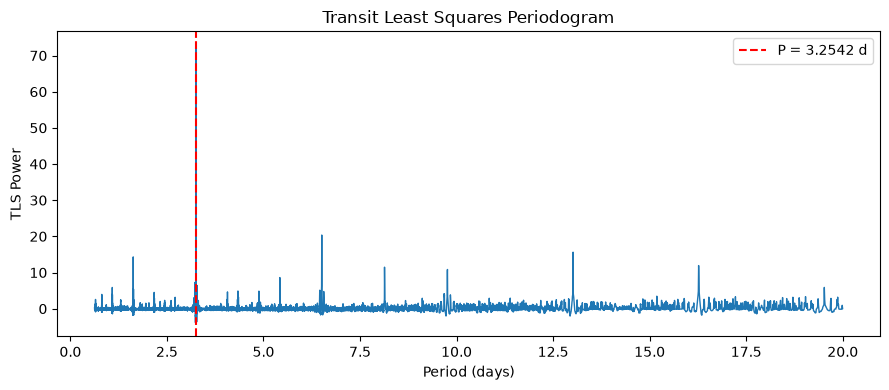

In [22]:
import matplotlib.pyplot as plt

raw = tls["_raw"]

plt.figure(figsize=(9,4))

plt.plot(
    raw.periods,
    raw.power,
    lw=1,
)

plt.axvline(
    tls["period"],
    color="red",
    ls="--",
    label=f"P = {tls['period']:.4f} d",
)

plt.xlabel("Period (days)")
plt.ylabel("TLS Power")
plt.title("Transit Least Squares Periodogram")

plt.legend()

plt.tight_layout()

plt.show()

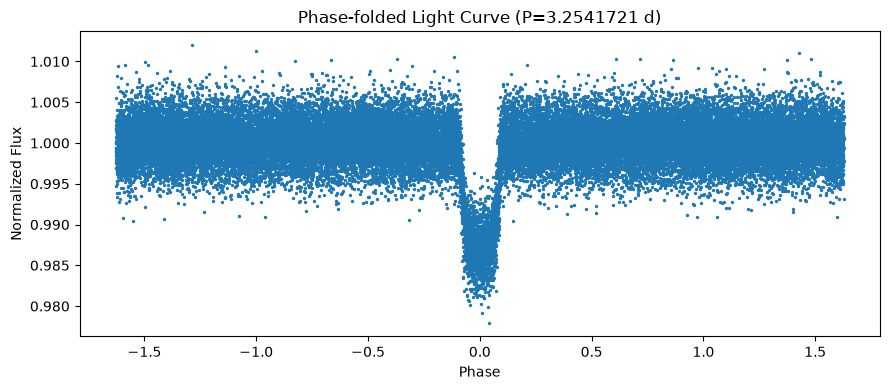

In [27]:
stitched_lc = lc_collection_2

period = tls["period"]
t0 = tls["epoch"]

phase = (
    (
        stitched_lc.time.value
        - t0
        + 0.5 * period
    )
    % period
) - 0.5 * period

idx = np.argsort(phase)

plt.figure(figsize=(9,4))

plt.scatter(
    phase[idx],
    stitched_lc.flux.value[idx],
    s=2,
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title(
    f"Phase-folded Light Curve (P={period:.7f} d)"
)

plt.tight_layout()

plt.show()

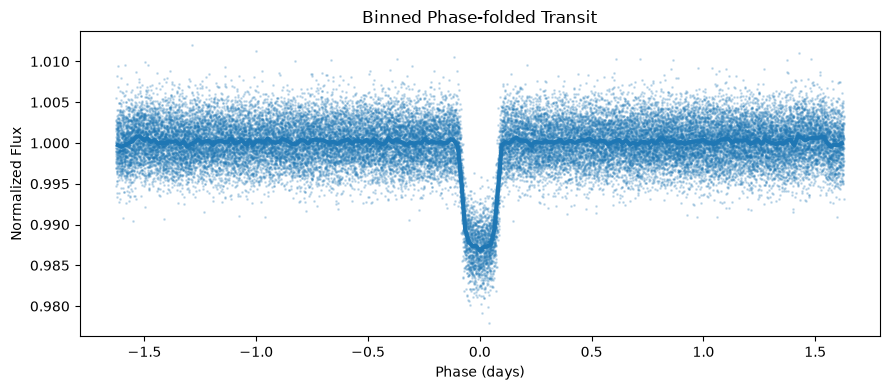

In [ ]:
from scipy.stats import binned_statistic

nbins = 200

bins = np.linspace(-0.5 * period, 0.5 * period, nbins)

median_flux, edges, _ = binned_statistic(
    phase,
    stitched_lc.flux.value,
    statistic="median",
    bins=bins,
)

centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(9,4))

plt.scatter(
    phase,
    stitched_lc.flux.value,
    s=1,
    alpha=0.2,
)

plt.plot(centers, median_flux, lw=3, color="C1")

plt.xlabel("Phase (days)")
plt.ylabel("Normalized Flux")
plt.title("Binned Phase-folded Transit")

plt.tight_layout()

plt.show()

In [24]:

#!/usr/bin/env python3
"""
Test script to run the TESS Exoplanet Pipeline with the modernized Bayesian (exoplanet/PyMC/GP)
backend on target star TIC {TIC}.
"""

from __future__ import annotations
import os
import sys
from tess_pipeline import TESSAnalysis

sectors = 'longest'  # Use 'longest' to automatically select the longest available sector for the target

def main(TIC) -> None:
    print(f"Initializing TESS Analysis for TIC {TIC} using Bayesian MCMC...")
    
    # Configure the analysis session with 500 tune and 500 draws for a fast test run
    analysis = TESSAnalysis(
        target=f"TIC {TIC}",
        inference=True,
        inference_backend="exoplanet",  # uses exoplanet/PyMC/celerite2
        search_method="tls",
        sectors=sectors,
        max_planets=2,
        chains=2,
        draws=1,
        tune=1,
        plots=True,
        output_dir=f"test_output_bayesian_sector_{sectors}_500_2",
        verbose=True
    )
    
    # Run the target characterization, download, detrending, and period search
    print("1. Resolving target coordinates...")
    analysis.resolve_target()

    print("2. Checking archival orbital period...")
    analysis.lookup_archive_period()
    
    print("3. Downloading TESS light curves from MAST...")
    analysis.load_lightcurves()
    
    print("4. Preprocessing light curves (stitching, cleaning, detrending)...")
    analysis.preprocess()
    
    print("5. Searching for transit signals...")
    analysis.search_period()
    
    # print("6. Querying Gaia DR3 for stellar properties...")
    # analysis.query_gaia()
    
    # print("7. Characterizing host star properties...")
    # analysis.characterize_star()
    
    # # Disable SDSS checking since it is deprecated/disabled
    # print("8. Skipping SDSS checking (disabled in this version)...")
    # analysis.query_sdss()
    
    # print("9. Running Bayesian MCMC fit...")
    # analysis.fit_transit()
    
    # print("10. Deriving physical planetary parameters with uncertainty propagation...")
    # analysis.derive_planet_parameters()
    
    # print("11. Checking MCMC sampler convergence...")
    # analysis.check_convergence()
    
    # print("12. Generating figures...")
    # analysis.generate_figures()
    
    # # Print results summary
    # print("\n" + "="*50)
    # print("BAYESIAN FIT RESULTS SUMMARY")
    # print("="*50)
    # analysis.results.summary()

    
    # print("\nSaving results and diagnostic plots...")
    # analysis.save()

    print("\nDone! Bayesian test completed successfully.\n")


    


Initializing TESS Analysis for TIC 381979901 using Bayesian MCMC...
1. Resolving target coordinates...
18:53:43  INFO      tess_pipeline.analysis.stages.target  Resolving target: TIC 381979901
18:53:43  DEBUG     tess_pipeline.data.metadata  Resolved 'TIC 381979901' to TIC 381979901
18:53:43  INFO      tess_pipeline.catalogs.nasa_archive  Using local NASA archive CSV /home/astro-nitesh/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline/data/TOI_2026.06.28_09.42.00.csv for TIC 381979901 (matched 1 row(s))
18:53:43  INFO      tess_pipeline.data.metadata  Loaded coordinates for TIC 381979901 from local archive
18:53:43  INFO      tess_pipeline.analysis.stages.target  Resolved to TIC 381979901
2. Checking archival orbital period...
18:53:43  INFO      tess_pipeline.analysis.stages.period  Querying NASA Exoplanet Archive for TIC 381979901
18:53:43  INFO      tess_pipeline.analysis.stages.period  Archive periods found: 1 planets (Primary: 3.254118 d)
3. Downloading TESS light curves fr

18:53:48  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 12/13: data/fits/tess2021118034608-s0038-0000000381979901-0209-s_lc.fits


18:53:49  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 13/13: data/fits/tess2021146024351-s0039-0000000381979901-0210-s_lc.fits
18:53:49  INFO      tess_pipeline.data.download  [fits] Step 4/4: loaded 13 light curve(s) from local FITS in 6.3s
18:53:49  INFO      tess_pipeline.analysis.stages.lightcurve  Loaded light curves for sector(s): [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
4. Preprocessing light curves (stitching, cleaning, detrending)...
18:53:49  INFO      tess_pipeline.analysis.stages.lightcurve  Preprocessing light curves
18:53:51  INFO      tess_pipeline.data.preprocess  Saving diagnostic plots to directory: test_output_bayesian_sector_longest_500_2/TIC 381979901/plots
18:53:51  INFO      tess_pipeline.data.preprocess  Dynamic mask width calculated: 0.178 days for P = 3.25 d
18:54:54  DEBUG     tess_pipeline.data.preprocess  Stitched 13 sectors -> 199366 cadences
18:54:54  INFO      tess_pipeline.data.preprocess  Preprocessing complete: 199

100%|██████████| 76/76 periods | 00:51<00:00


18:56:04  INFO      tess_pipeline.transit.tls  Optimized T0 search: running coarse pass with 100 points...
18:56:10  INFO      tess_pipeline.transit.tls  Optimized T0 search: running fine pass with 300 points around T0=2038.9079...
18:56:39  INFO      tess_pipeline.transit.tls  TLS: period=3.254154 d, epoch=2038.9052, duration=3.30 h, depth=0.013594, SDE=2.52
18:56:40  INFO      tess_pipeline.analysis.stages.period  Searching for 1 additional planet(s) in residuals...
18:56:40  INFO      tess_pipeline.transit.detection  Downsampled LC from 186372 → 37275 points (10-min cadence) for broad TLS search
18:56:40  INFO      tess_pipeline.transit.detection  Searching for Planet 1 candidate (coarse search)...
18:56:40  INFO      tess_pipeline.transit.detection  Running TLS (period 0.5–100.0 d)
18:56:40  DEBUG     tess_pipeline.transit.tls  TLS search mode: broad (osf=None, dur_step=1.10)
18:56:40  DEBUG     tess_pipeline.transit.tls  TLS kwargs: {'period_min': 0.5, 'period_max': 100.0, 'durati

100%|██████████| 500/500 periods | 01:02<00:00

18:57:43  INFO      tess_pipeline.transit.tls  Optimized T0 search: running coarse pass with 396 points...


18:57:45  INFO      tess_pipeline.transit.tls  Optimized T0 search: running fine pass with 300 points around T0=2072.0656...
18:57:51  INFO      tess_pipeline.transit.tls  TLS: period=48.577234 d, epoch=2072.0865, duration=1.40 h, depth=0.001390, SDE=0.28
18:57:51  INFO      tess_pipeline.transit.detection  Planet 1 coarse SDE/SNR (3.93) below threshold of 4.0. Stopping search.
18:57:51  INFO      tess_pipeline.analysis.stages.period  Detections completed. Found 1 planet candidate(s).
18:57:51  INFO      tess_pipeline.analysis.session  Saved step plot: test_output_bayesian_sector_longest_500_2/TIC 381979901/plots/03_tls_periodogram.png
18:57:53  INFO      tess_pipeline.analysis.session  Saved step plot: test_output_bayesian_sector_longest_500_2/TIC 381979901/plots/tls_periodogram_coarse_p0.png
18:57:55  INFO      tess_pipeline.analysis.session  Saved step plot: test_output_bayesian_sector_longest_500_2/TIC 381979901/plots/tls_periodogram_fine_p0.png
18:57:58  INFO      tess_pipeline.an

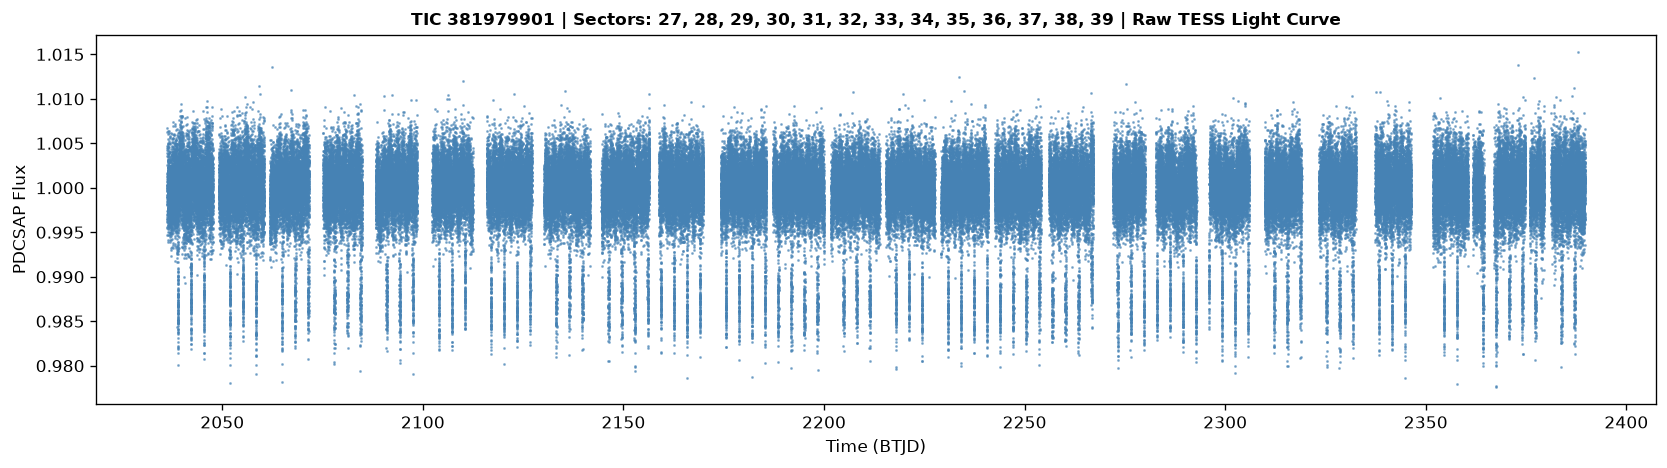

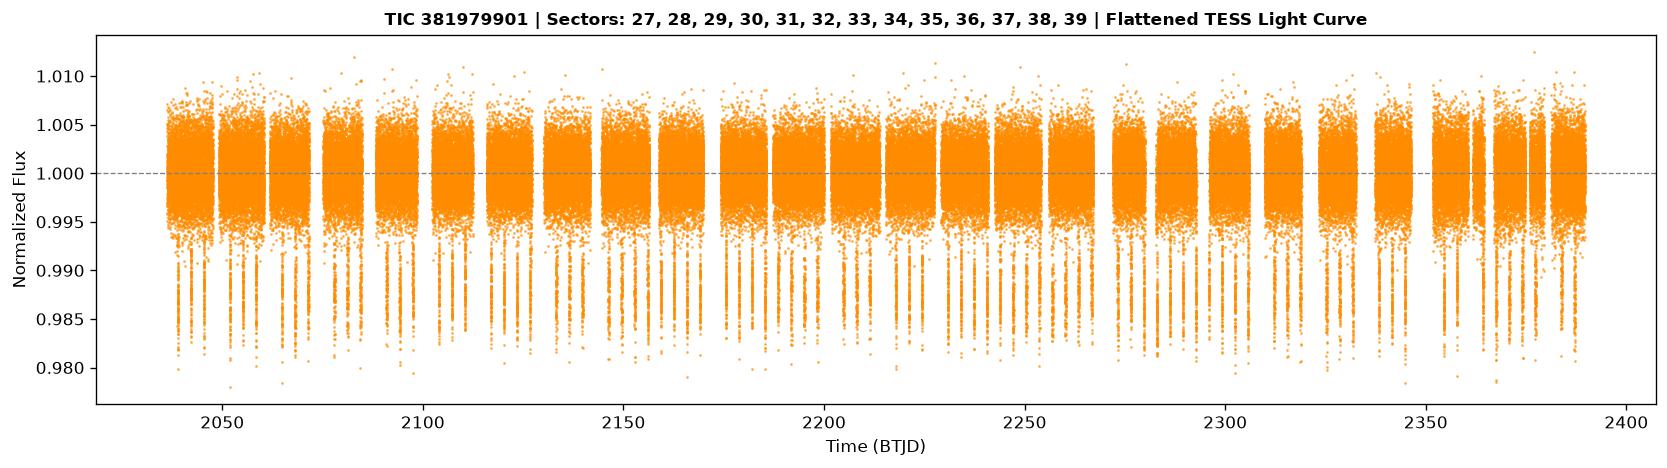

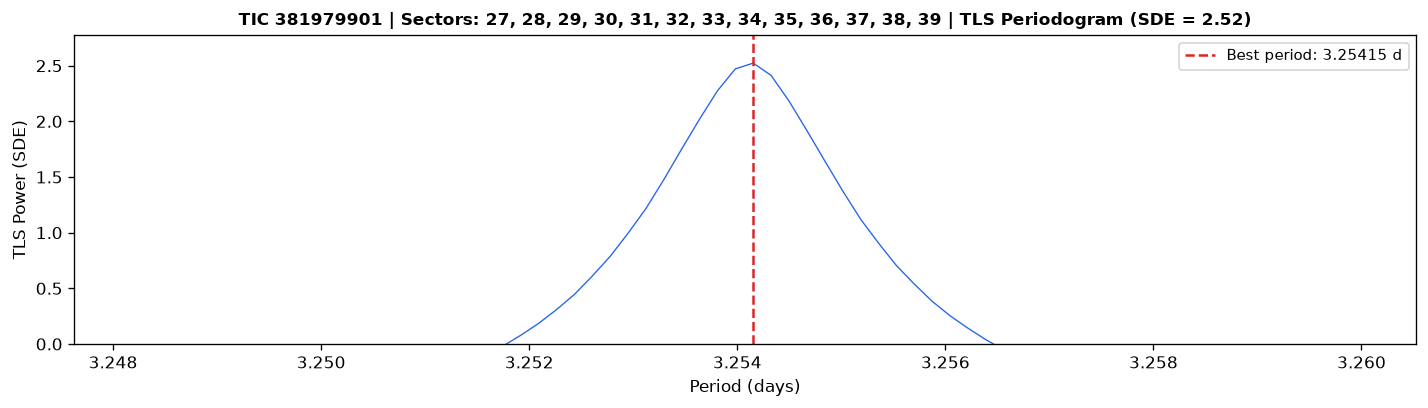

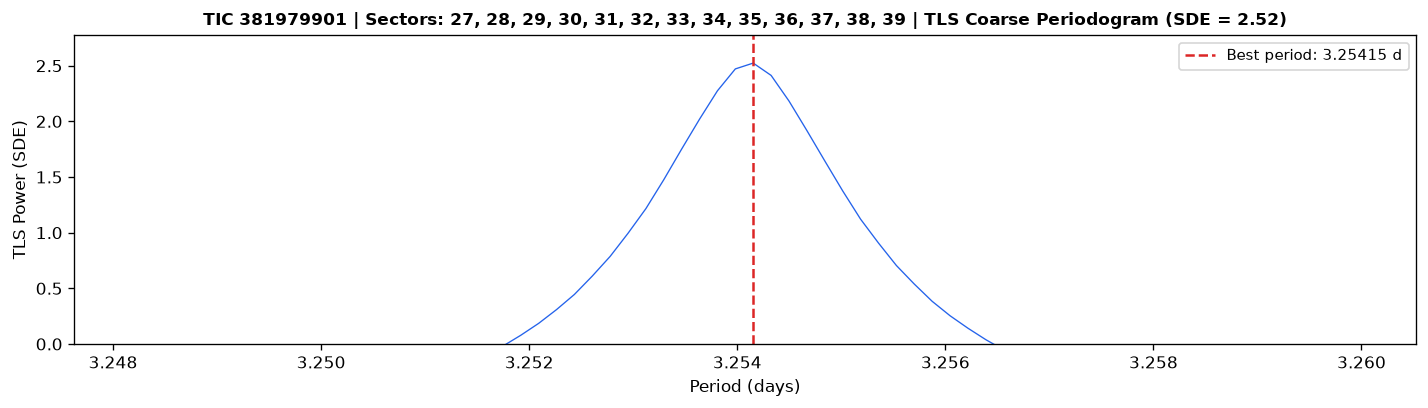

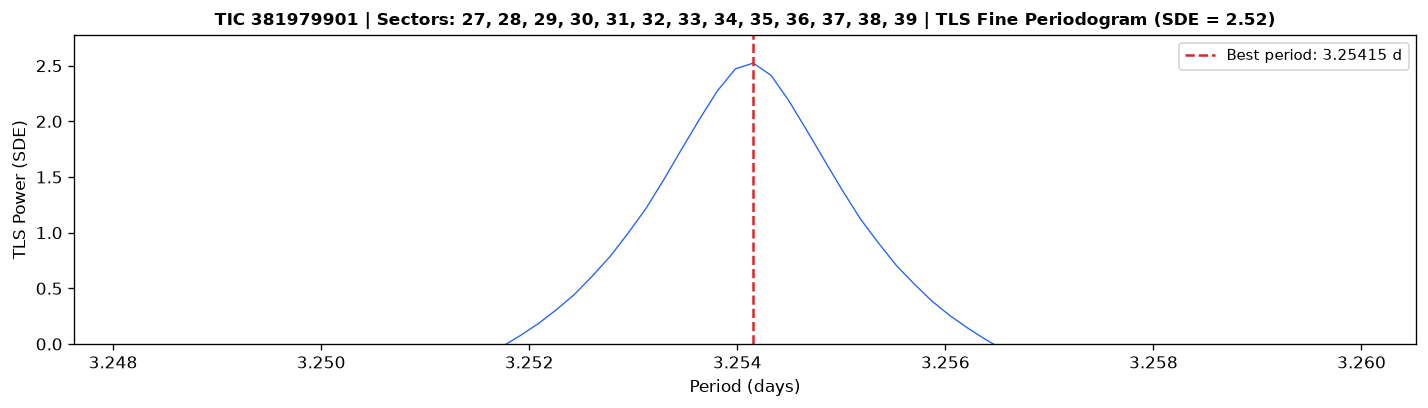

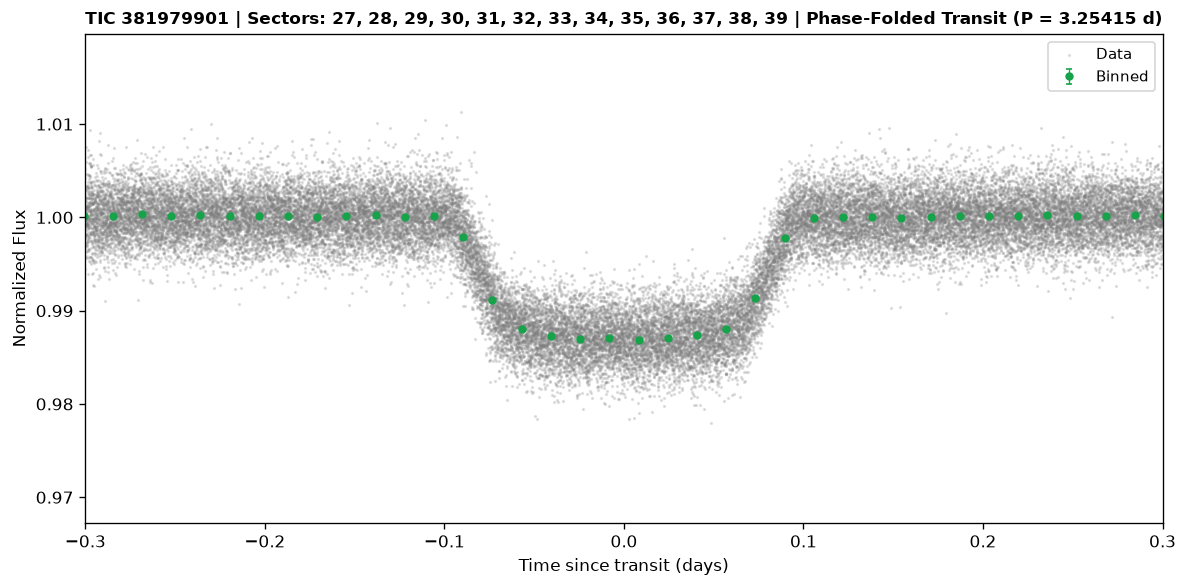

In [25]:
if __name__ == "__main__":
    main(tic_id_adopted)
